In [1]:
import importlib
import test_spf

#importlib.reload(test_spf)

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from galois import GF2
import tableau as ta

from gspf_ilp import create_graph_code, generalised_spf_logical
from test_spf import crazy_graph, sample_lost_nodes


0.0
0.1111111111111111
0.2222222222222222
0.3333333333333333
0.4444444444444444
0.5555555555555556
0.6666666666666666
0.7777777777777777
0.8888888888888888
1.0


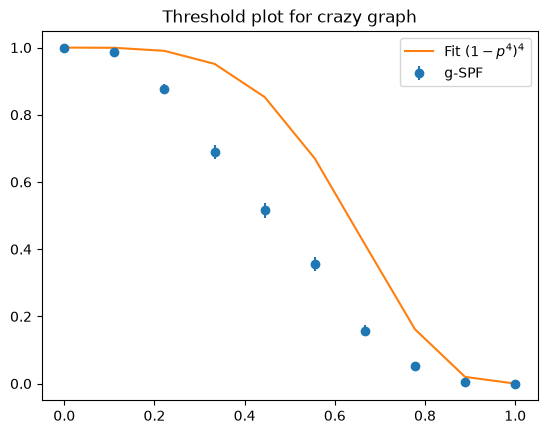

In [2]:

g = crazy_graph(4,4)
g = nx.to_numpy_array(g, dtype = np.uint16)
numq = g.shape[0]-1
xlogi, zlogi, stabi = create_graph_code(g)
gg = 1
previous_meas = []
previous_meas = [ta.paulistring2tableau(ele, numq) for ele in previous_meas]
T = GF2(stabi)

fail_list = []
fit = []
num_shots = 5_00

lost_prob = np.linspace(0,1,10)
for p in lost_prob:
    print(p)
    fail = 0

    for ele in range(num_shots):
        lq = sample_lost_nodes(g, p)
        lost_qubits = [0]*2*numq
        for ele in lq:
            lost_qubits[ele] = 1
            lost_qubits[ele+numq] = 1

        res = generalised_spf_logical(stabi, xlogi, zlogi, previous_meas, lost_qubits, gg, target_qubit=numq)
        if res["success"]:
            fail += 1

    fail_list.append(fail/num_shots)
    fit.append((1-p**4)**4)

fail_list = np.asarray(fail_list)
yerr =  np.sqrt(fail_list * (1 - fail_list) / num_shots)

plt.figure()
plt.title("Threshold plot for crazy graph")
# plt.plot(lost_prob, fail_list)
plt.errorbar(lost_prob, fail_list, yerr=yerr, fmt = "o", label = "g-SPF")
plt.plot(lost_prob, fit, label = r"Fit $(1-p^{4})^{4}$")
plt.legend()
plt.show()